# 14. Pacman with AI

In this practical lesson, students are working in pairs to learn about the inner workings of NeuralNetwork-based agents for game search via an interactive and engagin environment. It is a project about implementing a fairly simple net that is able to play the famously known game "Pacman", controlling the yellow agent, clearing the board and making sure not to be eaten by the ghosts. 

To implement this, we were given a github repository with the basics of the practice, based on UC Bekerley's AI projects (University of California), which some small tweaks to allow us to implement the neural network for agent decision-making.

This project comes with a couple key components, those being the following:
- **Game engine**, in `game.py`, implementing the main mechanics of the gameplay, as the name suggests. 
- **Pacman engine**, in `pacman.py`, which takes care of how our Pacman works.
- **Neural agent**, in `multiagents.py`, containing different agent and algorithm implementations. As we explain below, we have modified this doccument quite a lot to implement our heuritics, minimax, alphabeta, etc.
- **Ghost agents**, in `ghostAgents.py`, defining the different behaviours of the ghosts.
- **Data collection**, in `gamedata.py`, which will be crucial to record the games for training.
- **Replay functionality**, in `playback.py`, allowing games to be replayed and playing an important role in how we will be evaluated.
- **Utilities**, in `utils.py`, with various helper functions and data structures.

The first part of the practical session meant making up new heuristics and implementing them.

## 14.1. Part 1: New heuristics

(These have been implemented at `multiAgents.py`, starting at around line ~354).

### 14.1.1. "Approach power capsules" heuristic

We figured that **the agent would benefit from prioritizing going for power capsules** in
order to chase away ghosts and gain some leeway + extra score.

```
# Factor 3: Distancia a la cápsula de poder más cercana
        power_capsules = state.getCapsules()
        if power_capsules:
            min_capsule_distance = min(
                manhattanDistance(pacman_pos, cap_pos) for cap_pos in power_capsules
            )

            # Recompensa por acercarse a una cápsula
            score += 5.0 / (min_capsule_distance + 1)
```

We simply compute the distance to the closest power capsule, then make that inversely
proportional to our heuristic score (the closer to a capsule and the shorter the
distance, the better).

We've conservatively given the capsule heuristic a weight of `5.0`: large enough to be
more attractive than the plain food heuristic (# factor 1), but not attractive enough to
make the agent reckless and ignore the ghost positions.

However, it was at this point that we thought of a neat addition to this heuristic:

**"If the agent has already consumed a capsule and ghosts are currently under the 'scared'
effect, then further capsules should be strongly discouraged!"**

This matches how humans play the game, avoiding the waste of these useful resources
until they are truly needed:

```
# Factor 3: Distancia a la cápsula de poder más cercana
        power_capsules = state.getCapsules()

        if power_capsules:
            power_active = any(
                g.scaredTimer > 0 for g in ghost_states
            )  # detect power capsule effect
            min_capsule_distance = min(
                manhattanDistance(pacman_pos, cap_pos) for cap_pos in power_capsules
            )

            if not power_active:
                score += 5.0 / (min_capsule_distance + 1)
            else:
                # Strongly discourage consuming capsules while powered
                score -= 100.0 / (min_capsule_distance + 1)
```

We check whether the power capsule effect is active via the query:
``
power_active = any(g.scaredTimer > 0 for g in ghost_states)
``

If it is active, we discourage moving toward the nearest capsule with a weight of
`-100`. We've chosen this weight because it is large enough to be meaningful and
overpower the **'chase ghosts when under the capsule's effect'** heuristic. We deem
preserving power capsules more important than getting a handful of extra points from
eating ghosts.

### 14.1.2. "Avoid undoing moves" heuristic

We also figured that the agent would benefit from avoiding "undoing" moves it has just
done.

For instance: if the agent has just moved "right", it makes sense to discourage it from
moving "left" right afterward, unless there's a good reason to do so (e.g. ghosts are
approaching from the right).

In order to implement this, **the agent obviously needs a way of knowing what its last
action was**. We can easily achieve this via an instance attribute, though we'll also need
to make some small modifications at `multiAgents/NeuralAgent.getAction`, in order to
store the chosen action for the next iteration to use.

We defined the following helper in order to assist with this:

```
def _return_action(self, action):
    self.last_action = action
    return action
```

And modified all relevant `return` instances at `NeuralAgent.getAction()`.

Then, we simply added the following factor at `NeuralAgent.evaluationFunction()`:

```
# Factor 4: Discourage "undoing" moves
        opposites = {
            Directions.NORTH: Directions.SOUTH,
            Directions.SOUTH: Directions.NORTH,
            Directions.EAST: Directions.WEST,
            Directions.WEST: Directions.EAST,
        }

        if self.last_action in opposites:  # (last move might've been STOP)
            undo = opposites[self.last_action]
            if undo in legal_actions:
                score -= 10
```

We chose a weight of 10 because it's big enough to be visually noticeable, without
overpowering the "ghosts are near" and other important penalties.

### 14.1.3. Testing heuristics out

In [ ]:
!python pacman.py -p NeuralAgent

Modelo cargado correctamente desde models/pacman_model.pth
Tamaño de entrada: (20, 11)
NeuralAgent inicializado, usando dispositivo: cuda
Reply mode: False
Pacman died! Score: -442
Datos del juego 99 guardados en pacman_data/game_99.csv
Average Score: -442.0
Scores:        -442.0
Win Rate:      0/1 (0.00)
Record:        Loss


After a bunch of tries, we noticed that the game would always play out in the exact same
way.

This is because **Ahmed has fixed a random seed**. We'll replace it with a true random one
instead. In order to do this, we've created a `.env` file declaring a `PACMAN_SEED`
environment variable.
We've also created a new `config.py` file, where we extract said random (or fixed) seed
**only once**. We later import `PACMAN_SEED` from `config` wherever we need to use it.

Leaving it blank uses a random seed.

In [ ]:
!python pacman.py -p NeuralAgent

Modelo cargado correctamente desde models/pacman_model.pth
Tamaño de entrada: (20, 11)
NeuralAgent inicializado, usando dispositivo: cuda
Reply mode: False
Pacman died! Score: 272
Datos del juego 100 guardados en pacman_data/game_100.csv
Average Score: 272.0
Scores:        272.0
Win Rate:      0/1 (0.00)
Record:        Loss


Now our agent finally loads! Unfortunately, it plays terribly. We'll work on that in the
following lessons.

## Creating an automatic benchmarking tester with regex

In a similar spirit to my last practice, I've decided to create a regex-based automatic
testing function that sweeps through several agent + layout configurations and prints
out the results in a neat table format. -Pablo

[Regex](https://en.wikipedia.org/wiki/Regular_expression) (short for "regular expression") is a language for finding patterns in text. We'll use it to extract the relevant
data from the `pacman.py` execution results.

The function created may be found at `utils/parse_pacman_output.py`.

Additionally, we've created a battery of automated tests at
`tests/test_parse_pacman_output.py`.

These may be run via the command `python -m
unittest discover tests`.

We've also created a suite of helper functions at `utils/benchmark.py` to automate the
process of benchmarking several agents on several layouts. We'll test them out now:

In [ ]:
from utils import benchmark

layouts = ["mediumClassic"]
agents = ["NeuralAgent"]

benchmark(agents=agents, layouts=layouts, n_runs=5)
# note: this fails because we later modified the function to include an extra parameter.
# Originally, this would work properly and display an output. See examples of modern
# version below.

TypeError: benchmark() missing 1 required positional argument: 'neural_net_paths'

Additionally, we've created a couple of extra tests for the `benchmark()` function.
These may be found at `tests/test_benchmark.py`.

It is likely we'll need to tweak the function as the practice progresses.

## 14.2. Part 2: Network training

For this section, we've been tasked with providing the network with some high-quality
games for training.

It just so happens that one of the authors used to play a lot of classic pacman when
they were little. He had this modernized, 3d version for a handheld system that would
also include the classic version as an easter egg. He would play for hours at a time, so
they believe they're no beginner.

However, after a couple of lost rounds, we realized the author wasn't as great as he
believed. Only by lowering the `--frameTime` could he manage to win any games, and these
were few and far in between.

At this point, we realise **it'd be useful to have a helper function that scans a
directory containing training games and reports some useful statistics**, like the number
of games and the average score:

```
def load_training_stats(folder):
    """
    Reads all CSV game files in a folder and returns:
    - num_games: number of CSV files
    - avg_score: average final score across games
    """
    scores = []
    for file in os.listdir(folder):
        if file.endswith(".csv"):
            df = pd.read_csv(os.path.join(folder, file))
            # final score = score of last row
            scores.append(df["score"].iloc[-1])

    if not scores:
        return {"num_games": 0, "avg_score": 0.0}

    return {
        "num_games": len(scores),
        "avg_score": sum(scores) / len(scores),
    }
```

This function has been saved to `utils`, too.

Now, we can assess the quality of the training games the author has just played:

In [ ]:
from utils import load_training_stats

load_training_stats(folder="pacman_data_manual")

{'num_games': 11, 'avg_score': np.float64(1011.7272727272727)}

As we can see, we haven't managed to win many games, and the average score isn't super
impressive. Still, we can try training the network on this training set already:

In [ ]:
!python net.py --train --data pacman_data_manual --save models/only_manual_games.pth


Usando dispositivo: cuda
Archivos CSV encontrados: ['pacman_data/game_17.csv', 'pacman_data/game_6.csv', 'pacman_data/game_48.csv', 'pacman_data/game_51.csv', 'pacman_data/game_45.csv', 'pacman_data/game_14.csv', 'pacman_data/game_23.csv', 'pacman_data/game_12.csv', 'pacman_data/game_7.csv', 'pacman_data/game_35.csv', 'pacman_data/game_10.csv', 'pacman_data/game_0.csv', 'pacman_data/game_28.csv', 'pacman_data/game_38.csv', 'pacman_data/game_55.csv', 'pacman_data/game_19.csv', 'pacman_data/game_29.csv', 'pacman_data/game_33.csv', 'pacman_data/game_54.csv', 'pacman_data/game_1.csv', 'pacman_data/game_43.csv', 'pacman_data/game_41.csv', 'pacman_data/game_27.csv', 'pacman_data/game_30.csv', 'pacman_data/game_21.csv', 'pacman_data/game_20.csv', 'pacman_data/game_56.csv', 'pacman_data/game_37.csv', 'pacman_data/game_3.csv', 'pacman_data/game_52.csv', 'pacman_data/game_18.csv', 'pacman_data/game_42.csv', 'pacman_data/game_24.csv', 'pacman_data/game_49.csv', 'pacman_data/game_16.csv', 'pacman_

Here, it seems we were getting an error due to a layout mismatch across the games in the
training set.

However, the training set with
manual games we had just created only featured one layout. After further inspection,
we noticed that the training data folder path being used was hardcoded to be =
`"pacman_data"`, which did indeed feature games using different layouts.

We've removed the hard-coded path.

In [10]:
!python net.py --train --data pacman_data_manual --save models/only_manual_games.pth


Usando dispositivo: cuda
Archivos CSV encontrados: ['pacman_data_manual/game_6.csv', 'pacman_data_manual/game_7.csv', 'pacman_data_manual/game_10.csv', 'pacman_data_manual/game_0.csv', 'pacman_data_manual/game_1.csv', 'pacman_data_manual/game_3.csv', 'pacman_data_manual/game_4.csv', 'pacman_data_manual/game_8.csv', 'pacman_data_manual/game_9.csv', 'pacman_data_manual/game_5.csv', 'pacman_data_manual/game_2.csv']
Cargando 11 archivos de partidas...
Datos cargados: 1642 ejemplos
Forma de los datos de entrada: (1642, 20, 11)
Tamaño del mapa: 20x11
Modelo creado: PacmanNet(
  (fc1): Linear(in_features=220, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=5, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)
Comenzando entrenamiento por 100 épocas...
Epoch: 1/100, Batch: 10/21, Loss: 1.5593, Acc: 25.47%
Epoch: 1/100, Batch: 20/21, Loss: 1.5283, Acc: 25.70%
Epoch: 1/100, Train Loss: 

Training has been successful!

Also, as may be noticed, **we've minimally modified `net.py` to include an argument
parser**, so that we may modify things like:
- the training set employed (by specifying a different path)
- the path of the stored model once trained
- etc.

rather than sticking to the default values.

This was achieved via Python's default `argparse` library.

### 14.2.1. Heuristics only vs net trained with human games

Now that the pipeline for training + benchmarking is more complete, we can pit different
algorithms against one another using our `benchmark()` function.

However, we've noticed one other obstacle: **the pacman NN model path to be loaded by
`NeuralNet` is again
hard-coded!** So we're going to have to modify `pacman.py` so it can take a `model_path`
parameter, and then pass that onto the `NeuralAgent` constructor.

Fortunately for us, `pacman.py` already passess all keyword parameters after the `-a`
flag to whichever constructor is being requested. This will require some modifications
to our automatic benchmarking helper, though.

Before that, we can test that using the afromentioned syntax does indeed load a model
that behaves closer to the human games we've given it:

In [1]:
!python pacman.py -p NeuralAgent -a model_path=models/only_human_games.pth 

Modelo cargado correctamente desde models/only_human_games.pth
Tamaño de entrada: (20, 11)
NeuralAgent inicializado, usando dispositivo: cuda
Reply mode: False
Pacman died! Score: 223
Datos del juego 59 guardados en pacman_data/game_59.csv
Average Score: 223.0
Scores:        223.0
Win Rate:      0/1 (0.00)
Record:        Loss


And indeed it does! It behaves much closer to its training human games.

After modifying both our helpers and their associated tests to include a
`neural_net_paths` parameter, we're ready to benchmark:
- Heuristics-only `NeuralAgent` (default net)
vs
- Human-games `NeuralAgent`

In [1]:
from utils import benchmark

agents = ["NeuralAgent", "NeuralAgent"]
layouts = [None, None] # default layout
neural_net_paths = [None, "only_human_games.pth"]
n_runs = 2

benchmark(agents=agents, layouts=layouts, neural_net_paths=neural_net_paths, n_runs=n_runs)


=== Running NeuralAgent on default layout using default model (2 runs) ===
done

=== Running NeuralAgent on default layout using only_human_games.pth (2 runs) ===
done

======================================== SUMMARY ========================================
Agent           Layout          Model Path                     Runs  AvgScore   WinRate 
NeuralAgent     default layout  default model                  2     -89.5      0.00    
NeuralAgent     default layout  only_human_games.pth           0     0.0        0.00    


defaultdict(list,
            {('NeuralAgent',
              'default layout',
              'default model'): [{'died': True,
               'score': -314,
               'game_index': 174,
               'average_score': -89.5,
               'scores': [-314.0],
               'wins': 0,
               'games': 2,
               'win_rate': 0.0,
               'record': 'Loss'}],
             ('NeuralAgent',
              'default layout',
              'only_human_games.pth'): [{'died': False}]})

*For some reason, when requesting `pacman.py` for batched runs via the `-n` parameter,
the parsed output seems weird and malformed (see above; running `NeuralAgent` on `default
layout` with `only_human_games.pth` returns a dictionary with a single 'died' key).*

#### 14.2.1.1. Debugging our parser and benchmarking pipeline

##### 14.2.1.1.1. Debugging game parser

First, let's figure out what running the underlying command actually prints out:

In [4]:
!python pacman.py -p NeuralAgent -q -n 5 -a model_path="models/only_human_games.pth"

Modelo cargado correctamente desde models/only_human_games.pth
Tamaño de entrada: (20, 11)
NeuralAgent inicializado, usando dispositivo: cuda
Reply mode: False
Pacman died! Score: -420
Datos del juego 185 guardados en pacman_data/game_185.csv
Pacman died! Score: -234
Datos del juego 186 guardados en pacman_data/game_186.csv
Pacman died! Score: -349
Datos del juego 187 guardados en pacman_data/game_187.csv
Pacman died! Score: 283
Datos del juego 188 guardados en pacman_data/game_188.csv
Pacman died! Score: 428
Datos del juego 189 guardados en pacman_data/game_189.csv
Average Score: -58.4
Scores:        -420.0, -234.0, -349.0, 283.0, 428.0
Win Rate:      0/5 (0.00)
Record:        Loss, Loss, Loss, Loss, Loss


Perfect. Now let's see what our parser is catching:

In [ ]:
from utils import parse_pacman_output

output_above = """Modelo cargado correctamente desde models/only_human_games.pth
Tamaño de entrada: (20, 11)
NeuralAgent inicializado, usando dispositivo: cuda
Reply mode: False
Pacman died! Score: -420
Datos del juego 185 guardados en pacman_data/game_185.csv
Pacman died! Score: -234
Datos del juego 186 guardados en pacman_data/game_186.csv
Pacman died! Score: -349
Datos del juego 187 guardados en pacman_data/game_187.csv
Pacman died! Score: 283
Datos del juego 188 guardados en pacman_data/game_188.csv
Pacman died! Score: 428
Datos del juego 189 guardados en pacman_data/game_189.csv
Average Score: -58.4
Scores:        -420.0, -234.0, -349.0, 283.0, 428.0
Win Rate:      0/5 (0.00)
Record:        Loss, Loss, Loss, Loss, Loss"""

parsed = parse_pacman_output(output_above)
parsed

{'died': True,
 'score': -420,
 'game_index': 185,
 'average_score': -58.4,
 'scores': [-420.0],
 'wins': 0,
 'games': 5,
 'win_rate': 0.0,
 'record': 'Loss'}

Here, we can already tell that the parser is not catching all the scores being
outputted, as it was initially designed for single-run outputs.

This still doesn't answer the question why the output we saw above when running
`benchmark()` was malformed, but it's a step in the right direction. We'll fix the
parser so it properly handles batched outputs.

First, we've created a failing `test_parses_batched_output()` at `tests/test_parse_pacman_output.py`.

Next, we've modified `parse_pacman_output` so it passes this new failing test. However,
as the output has been reworked (to remove redundant fields), past tests now fail too.
We're going to rewrite them as well.

Namely, one of the "big" changes that is making everything else fail is the use of lists
for many of the output fields, so that it may be able to handle batched outputs.

Initial versions of the parser only outputted single values, for single-game outputs.
The tests were written with this old behaviour in mind.

In [6]:
!python -m unittest tests/test_parse_pacman_output.py

.......
----------------------------------------------------------------------
Ran 7 tests in 0.002s

OK


We've also rewritten `parse_pacman_output()`'s docstring to reflect the new changes.

##### 14.2.1.1.2. Debugging `benchmark()`

As a result of the changes performed, the benchmark tests at `tests/test_benchmark.py`
have also begun failing:

In [7]:
!python -m unittest tests/test_benchmark.py


=== Running ReflexAgent on mediumClassic using default model (1 runs) ===
done

======================================== BENCHMARK ========================================
Agent           Layout          Model Path                     Runs  AvgScore   WinRate 
ReflexAgent     mediumClassic   default model                  1     -366.0     0/1 (0.00)
E
=== Running ReflexAgent on smallClassic using default model (2 runs) ===
done

======================================== BENCHMARK ========================================
Agent           Layout          Model Path                     Runs  AvgScore   WinRate 
ReflexAgent     smallClassic    default model                  2     -335.0     0/2 (0.00)
F
ERROR: test_benchmark_expected_fields (tests.test_benchmark.TestBenchmark.test_benchmark_expected_fields)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/home/pablors/uni/search-algorithms/practice3/tests/test_benchmark.py", 

After much debugging and rewriting of our tests, we've managed to make them pass:

In [11]:
!python -m unittest tests/test_benchmark.py


=== Running ReflexAgent on mediumClassic using default model (1 runs) ===
done

======================================== BENCHMARK ========================================
Agent           Layout          Model Path           Runs  AvgScore   WinRate 
ReflexAgent     mediumClassic   default model        1     -392.0     0/1 (0.00)
.
=== Running ReflexAgent on smallClassic using default model (2 runs) ===
done

======================================== BENCHMARK ========================================
Agent           Layout          Model Path           Runs  AvgScore   WinRate 
ReflexAgent     smallClassic    default model        2     -346.5     0/2 (0.00)
.
----------------------------------------------------------------------
Ran 2 tests in 5.800s

OK


Now let's re-test our code snippet from earlier:

In [ ]:
from utils import benchmark

agents = ["NeuralAgent", "NeuralAgent"]
layouts = [None, None] # default layout
neural_net_paths = [None, "only_human_games.pth"]
n_runs = 2

benchmark(agents=agents, layouts=layouts, neural_net_paths=neural_net_paths, n_runs=n_runs)


=== Running NeuralAgent on default layout using default model (2 runs) ===
done

=== Running NeuralAgent on default layout using only_human_games.pth (2 runs) ===
done

======================================== BENCHMARK ========================================
Agent           Layout          Model Path           Runs  AvgScore   WinRate 
NeuralAgent     default layout  default model        2     -291.5     0/2 (0.00)
NeuralAgent     default layout  only_human_games.pth 0     0.0             0.0


{('NeuralAgent',
  'default layout',
  'default model'): {'game_indices': [239, 240], 'scores': [-288.0,
   -295.0], 'average_score': -291.5, 'win_rate': '0/2 (0.00)', 'wins': 0, 'games': 2, 'record': ['Loss',
   'Loss']},
 ('NeuralAgent',
  'default layout',
  'only_human_games.pth'): {'game_indices': [], 'scores': []}}

Welp, at least this time it's different! We're still getting some malformed output for
the keys `('NeuralAgent', 'default layout', 'only_human_games.pth')`, but in a different
way than before.

We're adding a new test to `tests/test_benchmark.py` to make sure we won't get this
behaviour anymore (name of test: `test_benchmark_multiple_inputs_expected_fields()`).

In [1]:
from utils import benchmark

agents = ["NeuralAgent", "NeuralAgent"]
layouts = [None, None] # default layout
neural_net_paths = [None, "models/only_human_games.pth"]
n_runs = 2

benchmark(agents=agents, layouts=layouts, neural_net_paths=neural_net_paths, n_runs=n_runs)


=== Running NeuralAgent on default layout using default model (2 runs) ===
done

=== Running NeuralAgent on default layout using models/only_human_games.pth (2 runs) ===
done

======================================== BENCHMARK ========================================
Agent           Layout          Model Path                          Runs  AvgScore   WinRate 
NeuralAgent     default layout  default model                       2     -414.5     0/2 (0.00)
NeuralAgent     default layout  models/only_human_games.pth         2     -173.5     0/2 (0.00)


{('NeuralAgent',
  'default layout',
  'default model'): {'game_indices': [272, 273], 'scores': [-363.0,
   -466.0], 'average_score': -414.5, 'win_rate': '0/2 (0.00)', 'wins': 0, 'games': 2, 'record': ['Loss',
   'Loss']},
 ('NeuralAgent',
  'default layout',
  'models/only_human_games.pth'): {'game_indices': [274,
   275], 'scores': [-380.0, 33.0], 'average_score': -173.5, 'win_rate': '0/2 (0.00)', 'wins': 0, 'games': 2, 'record': ['Loss',
   'Loss']}}

Finally! After some time, we realized that the `model_path` we were using was wrong (it
lacked the `models/*` prefix), and our entire `benchmark()` pipeline was failing
silently because of this.

We fixed the issue and made sure that our pipeline now raises an explicit
`ModelNotFoundError` whenever this happens again. Great!

### 14.2.2. Heuristics only vs net trained with human games (for real this time)

Now that everything is working as intended, we can run the comparison with `n_runs=20`.

In [3]:
from utils import benchmark

agents = ["NeuralAgent", "NeuralAgent"]
layouts = [None, None] # default layout
neural_net_paths = [None, "models/only_human_games.pth"]
n_runs = 20

benchmark(agents=agents, layouts=layouts, neural_net_paths=neural_net_paths, n_runs=n_runs)


=== Running NeuralAgent on default layout using default model (20 runs) ===
done

=== Running NeuralAgent on default layout using models/only_human_games.pth (20 runs) ===
done

======================================== BENCHMARK ========================================
Agent           Layout          Model Path                          Runs  AvgScore   WinRate 
NeuralAgent     default layout  default model                       20    -255.1     0/20 (0.00)
NeuralAgent     default layout  models/only_human_games.pth         20    -36.0      0/20 (0.00)


{('NeuralAgent',
  'default layout',
  'default model'): {'game_indices': [296,
   297,
   298,
   299,
   300,
   301,
   302,
   303,
   304,
   305,
   306,
   307,
   308,
   309,
   310,
   311,
   312,
   313,
   314,
   315], 'scores': [-476.0,
   -326.0,
   -101.0,
   -478.0,
   46.0,
   -114.0,
   -474.0,
   -505.0,
   -159.0,
   -504.0,
   -32.0,
   -364.0,
   89.0,
   -108.0,
   -503.0,
   -42.0,
   -175.0,
   50.0,
   -423.0,
   -502.0], 'average_score': -255.05, 'win_rate': '0/20 (0.00)', 'wins': 0, 'games': 20, 'record': ['Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss']},
 ('NeuralAgent',
  'default layout',
  'models/only_human_games.pth'): {'game_indices': [316,
   317,
   318,
   319,
   320,
   321,
   322,
   323,
   324,
   325,
   326,
   327,
   328,
   329,
   330,
   331,
   332,
   333,
   334,
 

**Surprisingly, just 10 good-ish games are enough to have the agent perform significantly
better than the naive, heuristics-only version.**

However, our agent is still far from being good, as may be told from the flat winrate.
Next, we'll attempt to train another Neural Model using our AlphaBeta agent.

### 14.2.3. Benchmarking a `NeuralAgent` trained on `AlphaBeta` games

#### 14.2.3.1. **Training** a `NeuralAgent` on `AlphaBeta` games

We're going to generate a bunch of training games using our `AlphaBetaAgent`:

In [6]:
!python pacman.py -p AlphaBetaAgent -n 100 -q

Reply mode: False
Pacman died! Score: 386
Datos del juego 0 guardados en pacman_data/game_0.csv
Pacman died! Score: 484
Datos del juego 1 guardados en pacman_data/game_1.csv
Pacman died! Score: 182
Datos del juego 2 guardados en pacman_data/game_2.csv
Pacman died! Score: 434
Datos del juego 3 guardados en pacman_data/game_3.csv
Pacman died! Score: 140
Datos del juego 4 guardados en pacman_data/game_4.csv
Pacman emerges victorious! Score: 1680
Datos del juego 5 guardados en pacman_data/game_5.csv
Pacman died! Score: 283
Datos del juego 6 guardados en pacman_data/game_6.csv
Pacman died! Score: 151
Datos del juego 7 guardados en pacman_data/game_7.csv
Pacman died! Score: 198
Datos del juego 8 guardados en pacman_data/game_8.csv
Pacman died! Score: 683
Datos del juego 9 guardados en pacman_data/game_9.csv
Pacman died! Score: 380
Datos del juego 10 guardados en pacman_data/game_10.csv
Pacman died! Score: 114
Datos del juego 11 guardados en pacman_data/game_11.csv
Pacman emerges victorious! 

In [7]:
!mv pacman_data/ pacman_data_alpha_beta_only

In [8]:
from utils import load_training_stats

load_training_stats("pacman_data_alpha_beta_only")

{'num_games': 100, 'avg_score': np.float64(850.76)}

As we can see, it seems the training games generated by `AlphaBeta` are not as high
quality as the ones we hand-crafted (we average 1000+ score), but there's an advantage
in being able to generate lots and lots of them. We'll make some more!

In [9]:
!python pacman.py -p AlphaBetaAgent -n 900 -q

Reply mode: False
Pacman died! Score: 406
Datos del juego 0 guardados en pacman_data/game_0.csv
Pacman died! Score: -94
Datos del juego 1 guardados en pacman_data/game_1.csv
Pacman died! Score: 228
Datos del juego 2 guardados en pacman_data/game_2.csv
Pacman died! Score: 290
Datos del juego 3 guardados en pacman_data/game_3.csv
Pacman died! Score: 67
Datos del juego 4 guardados en pacman_data/game_4.csv
Pacman died! Score: 313
Datos del juego 5 guardados en pacman_data/game_5.csv
Pacman emerges victorious! Score: 1458
Datos del juego 6 guardados en pacman_data/game_6.csv
Pacman died! Score: 198
Datos del juego 7 guardados en pacman_data/game_7.csv
Pacman died! Score: 102
Datos del juego 8 guardados en pacman_data/game_8.csv
Pacman died! Score: 99
Datos del juego 9 guardados en pacman_data/game_9.csv
Pacman emerges victorious! Score: 1654
Datos del juego 10 guardados en pacman_data/game_10.csv
Pacman died! Score: 364
Datos del juego 11 guardados en pacman_data/game_11.csv
Pacman died! S

*(We're gonna have to cut that early, because we don't have all day).*

In [10]:
!mv pacman_data/* pacman_data_alpha_beta_only/

In [11]:
load_training_stats("pacman_data_alpha_beta_only")

{'num_games': 135, 'avg_score': np.float64(864.0)}

*(As we can see, the average score hasn't changed much).*

Now we just need to train a new `NeuralAgent` with these games:

In [12]:
!python net.py --train --data pacman_data_alpha_beta_only/ --save models/only_alpha_beta.pth

Usando dispositivo: cuda
Archivos CSV encontrados: ['pacman_data_alpha_beta_only/game_101.csv', 'pacman_data_alpha_beta_only/game_17.csv', 'pacman_data_alpha_beta_only/game_129.csv', 'pacman_data_alpha_beta_only/game_6.csv', 'pacman_data_alpha_beta_only/game_48.csv', 'pacman_data_alpha_beta_only/game_51.csv', 'pacman_data_alpha_beta_only/game_106.csv', 'pacman_data_alpha_beta_only/game_105.csv', 'pacman_data_alpha_beta_only/game_45.csv', 'pacman_data_alpha_beta_only/game_62.csv', 'pacman_data_alpha_beta_only/game_14.csv', 'pacman_data_alpha_beta_only/game_102.csv', 'pacman_data_alpha_beta_only/game_83.csv', 'pacman_data_alpha_beta_only/game_23.csv', 'pacman_data_alpha_beta_only/game_130.csv', 'pacman_data_alpha_beta_only/game_115.csv', 'pacman_data_alpha_beta_only/game_116.csv', 'pacman_data_alpha_beta_only/game_96.csv', 'pacman_data_alpha_beta_only/game_95.csv', 'pacman_data_alpha_beta_only/game_66.csv', 'pacman_data_alpha_beta_only/game_125.csv', 'pacman_data_alpha_beta_only/game_63.

Aight, let's see how it fares!

#### 14.2.3.2. Actually benchmarking newly-trained `NeuralAgent` on `AlphaBetaGames`

In [2]:
from utils import benchmark

agents = ["NeuralAgent", "NeuralAgent", "AlphaBetaAgent", "NeuralAgent"]
layouts = [None]*4
model_paths = [
    None,
    "models/only_human_games.pth",
    None,
    "models/only_alpha_beta.pth",
    ]
n_runs = 100

benchmark(agents=agents, layouts=layouts, neural_net_paths=model_paths, n_runs=n_runs)


=== Running NeuralAgent on default layout using default model (100 runs) ===
done

=== Running NeuralAgent on default layout using models/only_human_games.pth (100 runs) ===
done

=== Running AlphaBetaAgent on default layout using default model (100 runs) ===
done

=== Running NeuralAgent on default layout using models/only_alpha_beta.pth (100 runs) ===
done

======================================== BENCHMARK ========================================
Agent           Layout          Model Path                          Runs  AvgScore   WinRate 
NeuralAgent     default layout  default model                       100   -217.0     0/100 (0.00)
NeuralAgent     default layout  models/only_human_games.pth         100   86.3       0/100 (0.00)
AlphaBetaAgent  default layout  default model                       100   411.2      5/100 (0.05)
NeuralAgent     default layout  models/only_alpha_beta.pth          100   113.7      0/100 (0.00)


{('NeuralAgent',
  'default layout',
  'default model'): {'game_indices': [89,
   90,
   91,
   92,
   93,
   94,
   95,
   96,
   97,
   98,
   99,
   100,
   101,
   102,
   103,
   104,
   105,
   106,
   107,
   108,
   109,
   110,
   111,
   112,
   113,
   114,
   115,
   116,
   117,
   118,
   119,
   120,
   121,
   122,
   123,
   124,
   125,
   126,
   127,
   128,
   129,
   130,
   131,
   132,
   133,
   134,
   135,
   136,
   137,
   138,
   139,
   140,
   141,
   142,
   143,
   144,
   145,
   146,
   147,
   148,
   149,
   150,
   151,
   152,
   153,
   154,
   155,
   156,
   157,
   158,
   159,
   160,
   161,
   162,
   163,
   164,
   165,
   166,
   167,
   168,
   169,
   170,
   171,
   172,
   173,
   174,
   175,
   176,
   177,
   178,
   179,
   180,
   181,
   182,
   183,
   184,
   185,
   186,
   187,
   188], 'scores': [31.0,
   -461.0,
   -384.0,
   -314.0,
   -472.0,
   366.0,
   -497.0,
   -231.0,
   -416.0,
   165.0,
   -506.0,
   -372.0,
  

## 14.3. Part 3: Implementing `AlphaBetaNeuralAgent`

AlphaBetaNeuralAgent is described to us as a class that inherits from the Alpha-Beta algorithm whose evaluation function is weighted, it being the following: 
`final_score = w_heuristic * traditional_score + w_neural * neural_score`
Being `w_heuristic` and `w_neural` the weights of both scores. 

Before implementing this version, it's clear that we need to create the AlphaBeta algorithm, which is based off the minimax algorithm, which will be explain in the following section. 

### 14.3.1 Implement minimax algorithm

Minimax is a decision-based algorithm often used is AI which tries to maximise the score a player can get in a game, always assuming both players are experts which fully know the rules of the game and will always make the optimal decision. It is commonly seen in games with adversaries, such as Tic-Tac-Toe, Chess or, as we can see by the theme of this project, PacMan (havintg the ghosts as the rivals).

Our class `MinimaxAgent` inherits from `MultiAgentSearchAgent`, already implemented in the code we were given. It starts with a fuction, `getAction`, which receives the current state of the game, inside of which we define the minimax recursive function, with the following parameters: 
- AgentIndex, which is a number that indicates if the Agent is Pacman (in which case it would be a 0) or a ghost (any number greater than 0). This will be crucial for implementing the algorithm, as depending on whose turn it is, the algorithm will need to maximise or minimse the score. 
- Depth, which is the current depth of the game, as the name of the variable suggests.
- GameState, which is the current state of the game, which we need to decide what our next move will be.

The first thing we need to take into account is the base case: when will the recursion end? We have three base cases: **we win the game**, which we can know with `gameState.isWin()`; **we lose the game**, which would be gameState.isLose(); or if the current depth is the depth of the whole game, it being `self.depth`. If we encounter any of those cases, we will return the evaluationFunction for said gameState. The code for this part of the function is the following: 

```
class MinimaxAgent(MultiAgentSearchAgent):

    def getAction(self, gameState: GameState):

        def minimax(agentIndex: int, depth, gameState: GameState):


            if gameState.isWin() or gameState.isLose() or depth == int(self.depth):
                #if it's a win, a lose, or the maximum depth, we can't do anything else
                return self.evaluationFunction(gameState)
```   



After that, we need to figure out whose turn it is: the ghosts' or Pacman's? If agentIndex is 0, Pacman is playing, in which case we will have to find the maximum value; otherwise, the ghost will need to get the minimum value. 
```
if agentIndex == 0:
    #if the agent is pacman, we want to get the maximum value
    return maxValue(agentIndex, depth, gameState)
            
else:
    #if the agent is a ghost, it watns to get the minimum value
    return minValue(agentIndex, depth, gameState)
```

To get the maximum value, we define a new function, `maxValue`, which receives the following arguments: 
- AgentIndex, which doesn't matter as much because Pacman will always be 0
- Depth
- GameState

First thing we do is set initally set the best value as the worst possible one, it being -infinite", and getting all the legal actions said agent can do. If we have no legal actions, we will return de the evaluation function of that gameState. 

If we do have legal actions, we will check each one of them to find the best score we can get from all of them. We then get the successor (it being the state of the game after taking said action) and find the best, which will be the maximum between our current best and the score the minimax function finds, with *agentIndex* being now 1 as it is the first ghost's turn.

```
def maxValue(agentIndex: int, depth, gameState: GameState):

    best = float('-inf') #we intially set the worst possible value as best to get the best one
    legal_actions = gameState.getLegalActions(agentIndex)

    if not legal_actions: 
        return self.evaluationFunction(gameState)

    else: 
        for action in legal_actions: #we try each of the actions: 
            #we get the next state after said action and we call minimax until no legal_actions are found, or
            #the game ends
            successor = gameState.generateSuccessor(agentIndex, action)
            best = max(best, minimax(1, depth, successor)) #next it's the ghost's turn
        return best
```

The next part of the code is fairly similar to `maxValue`, as we instead calculate the minimumValue, as the ghosts are trying to make PacMan lose. Instead of initialising *best* as minus infinite, we now have *worst* at infinite, and just like we did before, we check if we have any legal actions we can take.

The main difference needed to be pointed out is how we choose the next agent, as the number of ghosts in the game varies. What we do is find the total number of agents. If the current agent index + 1 is smaller than the number of agents, we simply do the addition, but if it's greater than it, the next agent will be 0 (Pacman) and we must add one to the depth. The rest of the logic is the same. 

```
def minValue(agentIndex: int, depth: int, gameState: GameState):

    worst = float('inf')
    legal_actions = gameState.getLegalActions(agentIndex)
    if not legal_actions: 
        return self.evaluationFunction(gameState)
            
    else:
        #here we have to keep in mind the number of agents we have:
        #the next agent will be agentIndex + 1 UNLESS the current agent is the last one before Pacman's turn
        num_agents = gameState.getNumAgents()
        #next_agent, depth = agentIndex + 1, depth if agentIndex +1 < num_agents else 0, depth +1
        if agentIndex + 1 < num_agents:
            next_agent = agentIndex + 1
            next_depth = depth
        else:
            next_agent = 0
            next_depth = int(depth) + 1

        for action in legal_actions: 
            successor = gameState.generateSuccessor(agentIndex, action)
            worst = min(worst, minimax(next_agent, next_depth, successor))
        return worst
```

Lastly, we need to chose the next action. First, we initialise a set of variables:
- best_action is initialised as None
- best_score if negative infinite

We check all possible actions Pacman (the one "starting") has, and calculate the score it can get from its successor with the minimax function. If said score is bigger than we one we already had, we save it as the current best score and the best action, which the function will eventually return. We will only calculate the best score and not the worst because it's impossible to play as the rival, we will always be Pacman and never a ghost.

``` 
#time to chose the next action: 
best_action = None
best_score = float('-inf')
for action in gameState.getLegalActions(0): #pacman starts
    successor = gameState.generateSuccessor(0, action)
    score = minimax(1, 0, successor)

    if score > best_score:
        best_score = score
        best_action = action
    #best_score, best_action = score, action if score > best_score else best_score, best_action

return best_action
```

### 14.3.2 Alpha-beta

After implementing the minimax, we extend it with Alpha-beta prunning, an optimisation technique which reduces the number of nodes explored by prunning those who would not get chosen. The algorithm keeps two different values, alpha and beta, representing the best scores for MAX and MIN. If at any given moment alpha becomes greater or equal than beta, the branch is prunnes, as it would not influence the final decision.

The code we implemented is very similar to the one for minimax, adding the prunning part. Once again, we have the `get_action` function, which receives the gameState. This time, we start by defining some variables:
- Alpha, initialised at minus infinite
- Beta, which starts as infinite
- Best action, which we have none yet
- Best score, initialised as minus infinite just like last time.


```
class AlphaBetaAgent(MultiAgentSearchAgent):

    def getAction(self, gameState: GameState):
 
        alpha = float('-inf')
        beta = float('inf')
        best_action = None
        best_score = float('-inf')
```

Then we define the `alphabeta` function, receiving agentIndex, depth, the gameState, alpha and beta. Just like last time, if the state is a win, a lose or the depth is *self.depth*, we return the evaluation function of said game state. Otherwise, we continue.

Firstly, we focus on Pacman, agent 0. we set a variable called `max_eval` initialised at minus infinite. For each legal action, we generate its successor and find the evaluation returned by the alphabeta funcion of said successor. After, we update max_eval with the new score is it's higher than the one we had, and we do the same with alpha. If beta is less or equal than alpha, a we mentioned before, we break the *for*, successfully prunning. Lastly, we return the maximum evaluation we got.

```
def alphabeta(agentIndex: int, depth, gameState: GameState, alpha: float, beta: float):
    if depth == self.depth or gameState.isWin() or gameState.isLose():
        return self.evaluationFunction(gameState)
    else:
        if agentIndex == 0: 
            max_eval = float('-inf')
            for action in gameState.getLegalActions(agentIndex):
                successor = gameState.generateSuccessor(agentIndex, action)
                eval_score = alphabeta(1, depth, successor, alpha, beta)
                max_eval = max(max_eval, eval_score)
                alpha = max(alpha, eval_score)
                if beta <= alpha: #prune, or "poda" as we studied in class
                    break
            return max_eval
```

Secondly, we focus on any other agent that isn't 0: the ghosts. Instead of `max_eval`, we now have `min_eval`. Then, we need to check who will be the next agent: another ghost or Pacman. The rest code is essencially the same as for Pacman, but finding the minimum evaluation instead of the maximum one. 

```
else: #if it isn't pacman
    min_eval = float('inf')
    for action in gameState.getLegalActions(agentIndex):
        successor = gameState.generateSuccessor(agentIndex, action)
        if agentIndex + 1 < gameState.getNumAgents():
            next_agent = agentIndex + 1
            next_depth = depth
        else:
            next_agent = 0
            next_depth = int(depth) + 1
            eval_score = alphabeta(next_agent, next_depth, successor, alpha, beta)
            min_eval = min(min_eval, eval_score)
            beta = min(beta, eval_score)
            if beta <= alpha: #pruning
                break
            return min_eval
```

Finally, we find the best action the same way we did with minimax. 

```
legal_actions = gameState.getLegalActions(0) #we start with pacman 
for action in legal_actions: 
    successor = gameState.generateSuccessor(0, action)
    score = alphabeta(1, 0, successor, alpha, beta)

    if score > best_score:
        best_score = score
        best_action = action
        alpha = max(alpha, score)
        
return best_action
```

### 14.3.3 AlphaBetaNeuralAgent

For this section, we were tasked with creating a new agent class that would:
- **perform search like `AlphaBetaAgent`**
- but **combine both
heuristics and a NN evaluation** as its evaluation function once depth limits were
reached
- allow the user to tweak the weights given to either component of the evaluation function

Therefore, we had the idea of making the `AlphaBetaNeuralAgent` class inherit from both
`AlphaBetaAgent` (for the alpha-beta search) and from `NeuralAgent` (for the heuristics
and NN evaluation).

### 14.3.3. Part 3.1.: Breaking down `NeuralAgent`'s `evaluationFunction` into two clear parts

However, at this point we ran into a seeming problem. We needed to weight the use of
heuristics vs the NN's evaluation separately. But `NeuralAgent` already combined both
things in
its `evaluationFunction`, indistinctly.

This seemed very weird to us. Does it make sense that we've already been using a sort of
'heuristics + NN hybrid' up until this point? Still, it was Ahmed who provided the code after
all, and instructed us to include the heuristics in that very function. So we decided not
to question this design choice and move on with our idea.

#### 14.3.3.1.1. Part 3.1.1.: Extracting `neural_eval()`

First we extracted the following into a separate `neural_eval()` method:

```
def neural_eval(self, state) -> float:
        """
        Provides a valuation of a given pacman state using exclusively the NN's trained
        output.

        Parameters
        ----------
        state
            The board state to evaluate.

        Returns
        -------
        neural_score: float
            NN-based valuation of `state`. Will always be `0` if no model is loaded.
        """
        if self.model is None:
            return 0  # Si no hay modelo, devolver 0

        # Convertir a matriz
        state_matrix = self.state_to_matrix(state)

        # Convertir a tensor
        state_tensor = torch.FloatTensor(state_matrix).unsqueeze(0).to(self.device)

        # Obtener predicciones
        with torch.no_grad():
            output = self.model(state_tensor)
            probabilities = torch.nn.functional.softmax(output, dim=1).cpu().numpy()[0]

        # Obtener acciones legales
        legal_actions = state.getLegalActions()

        # puntuación de la red
        neural_score = 0
        for i, action in enumerate(self.idx_to_action.values()):
            if action in legal_actions:
                neural_score += probabilities[i] * 100

        return neural_score
```

#### 14.3.3.1.2. Part 3.1.2.: Extracting `heuristic_eval()`

Next, we extracted `heuristic_eval()` into a separate `NeuralAgent` method:

```
def heuristic_eval(self, state) -> float:
        """
        Provides a valuation of a given pacman state using exclusively human-written heuristics.
        output.

        Parameters
        ----------
        state
            The board state to evaluate.

        Returns
        -------
        heuristic_score: float
            heuristic-based valuation of `state`.
        """
        # Aplicar heurísticas adicionales, similar a betterEvaluationFunction
        heuristic_score = state.getScore()

        # Mejorar la evaluación con conocimiento del dominio
        pacman_pos = state.getPacmanPosition()
        food = state.getFood().asList()
        ghost_states = state.getGhostStates()
        legal_actions = state.getLegalActions()

        # Factor 1: Distancia a la comida más cercana
        if food:
            min_food_distance = min(
                manhattanDistance(pacman_pos, food_pos) for food_pos in food
            )
            heuristic_score += 1.0 / (min_food_distance + 1)

        # Factor 2: Proximidad a fantasmas
        for ghost_state in ghost_states:
            ghost_pos = ghost_state.getPosition()
            ghost_distance = manhattanDistance(pacman_pos, ghost_pos)

            if ghost_state.scaredTimer > 0:
                # Si el fantasma está asustado, acercarse a él
                heuristic_score += 50 / (ghost_distance + 1)
            else:
                # Si no está asustado, evitarlo
                if ghost_distance <= 2:
                    heuristic_score -= (
                        200  # Gran penalización por estar demasiado cerca
                    )

        # Factor 3: Distancia a la cápsula de poder más cercana
        power_capsules = state.getCapsules()

        if power_capsules:
            power_active = any(
                g.scaredTimer > 0 for g in ghost_states
            )  # detect power capsule effect
            min_capsule_distance = min(
                manhattanDistance(pacman_pos, cap_pos) for cap_pos in power_capsules
            )

            if not power_active:
                heuristic_score += 5.0 / (min_capsule_distance + 1)
            else:
                # Strongly discourage consuming capsules while powered
                heuristic_score -= 100.0 / (min_capsule_distance + 1)

        # Factor 4: Discourage "undoing" moves
        opposites = {
            Directions.NORTH: Directions.SOUTH,
            Directions.SOUTH: Directions.NORTH,
            Directions.EAST: Directions.WEST,
            Directions.WEST: Directions.EAST,
        }

        if (
            hasattr(self, "last_action") and self.last_action in opposites
        ):  # (last move might've been STOP)
            undo = opposites[self.last_action]
            if undo in legal_actions:
                heuristic_score -= 10

        return heuristic_score
```

Therefore, after these changes, `NeuralAgent.evaluationFunction()` ends up looking like
this:

```
def evaluationFunction(self, state) -> float:
        """
        Una función de evaluación basada en la red neuronal y en heurísticas
        adicionales.

        Heurísticas adicionales
        -----------------------
        - Prefer going toward power capsules.
        - Avoid going for further power capsules when under the effect of one.
        - Avoid 'undoing' moves unless necessary.
        """

        heuristic_score: float = self.heuristic_eval(state=state)
        neural_score: float = self.neural_eval(state=state)

        return heuristic_score + neural_score
```

Amusingly, this is already very close to what we want `AlphaBetaNeuralAgent`'s
evaluation function to be, just with tweakable weights!

#### 14.3.3.2. Part 3.2.: Actually implementing `AlphaBetaNeuralAgent`

Once the above was sorted out, implementing the hybrid agent was as easy as:

```
# AlphaBeta con pesos:
class AlphaBetaNeuralAgent(AlphaBetaAgent, NeuralAgent):
    """
    Implements the Alpha-Beta algorithm with a weighted eval function, giving the result
    final_score = w_heuristic * heuristic_score + w_neural * neural_score
    """

    def __init__(
        self,
        w_heuristic=0.5,
        w_neural=0.5,
        model_path="models/pacman_model.pth",
        depth="2",
    ) -> None:
        """
        Constructor of the class

        Args
        ----
        w_heuristic (float) -> the weight of the heuristic part of the eval function.
        w_neural (float) -> the weight of the neural part of the eval function.
        """

        # Initialize AlphaBetaAgent (search logic)
        AlphaBetaAgent.__init__(self, depth=depth)

        # Initialize NeuralAgent (eval functions)
        NeuralAgent.__init__(self, model_path=model_path)

        self._w_heuristic = w_heuristic
        self._w_neural = w_neural

        if self._w_heuristic + self._w_neural != 1:
            self.normalise()

    def normalise(self) -> None:
        """Normalises the weights to make sure they don't excede 1
        This is a method I decided to include in case any mistake is made when receiving the weight parameters,
        it wasn't asked in the practice :)
        """
        total = self._w_heuristic + self._w_neural
        if total == 0:
            return
        self._w_heuristic /= total
        self._w_neural /= total

    def evaluationFunction(self, state) -> float:

        heuristic_score: float = self.heuristic_eval(state=state)
        neural_score: float = self.neural_eval(state=state)

        return self._w_heuristic * heuristic_score + self._w_neural * neural_score
```

Couple noteworthy things:
- the `__init__` constructor must call both the `AlphaBetaAgent` constructor (to inherit
  search logic) and the `NeuralAgent` constructor (to inherit NN logic and the eval
  functions).
- we added a self-normalizing method for the agent weights, used in the constructor.

As can be seen, the final eval score is simply computed as the **weighted sum** of the separate
heuristic + neural evals.

**We've chosen 0.5/0.5 weights as the default**, believing it to be a good starting point
for further tweaking and fine-tuning.

### 14.3.4 Implementing AlphaBetaNeuralDynamicWeightsAgent

Note: this was made after all the benchmarking was done, so it will all be explained in this section.

We decided to implement a version of `AlphaBetaNeuralAgent` which uses dynamic weights instead of the static ones we've been using by making a class which inherits from it. We decided to add an instance variable, which we called `call_count`, which starts at 0, and increases by one each time the `evaluationFunction` is called, and divide the neural weight by it. Then, the heuristic weight is calculated as one minus the dynamic neural weight. This way, as time passes, the weights will favour the heuristic score and decrease the value of the neural score.

The new `evaluationFunction` is as easy as it can get: 

```    
def evaluationFunction(self, state) -> float:

    self.call_count += 1

    heuristic_score: float = self.heuristic_eval(state=state)
    neural_score: float = self.neural_eval(state=state)
    dynamic_w_neural = self._w_neural / self.call_count
    dynamic_w_heuristic = 1 - dynamic_w_neural

    return dynamic_w_heuristic * heuristic_score + dynamic_w_neural * neural_score
```

We decided to run the benchmarks and compare our `AlphaBetaNeuralAgent` and the dynamic weighted version of it to test whether this implementation gets a better result. We did 30 games for each agent, with both models and both mazes.

In [1]:
from utils import benchmark

agents = ["AlphaBetaNeuralAgent"]*2 +['AlphaBetaNeuralDynamicWeightsAgent']*2

layouts = ["mediumClassic", "mediumClassic", "customMaze", "customMaze"]

model_paths = ["models/only_alpha_beta.pth", "models/only_human_games.pth"] * 2

n_games = 30

benchmark(agents=agents, layouts=layouts, neural_net_paths=model_paths, n_runs=n_games)


=== Running AlphaBetaNeuralAgent on mediumClassic using models/only_alpha_beta.pth (30 runs) ===
done

=== Running AlphaBetaNeuralAgent on mediumClassic using models/only_human_games.pth (30 runs) ===
done

=== Running AlphaBetaNeuralDynamicWeightsAgent on customMaze using models/only_alpha_beta.pth (30 runs) ===
done

=== Running AlphaBetaNeuralDynamicWeightsAgent on customMaze using models/only_human_games.pth (30 runs) ===
done

======================================== BENCHMARK ========================================
Agent                     Layout          Model Path                          Runs  AvgScore   WinRate 
AlphaBetaNeuralAgent      mediumClassic   models/only_alpha_beta.pth          30    395.2      0/30 (0.00)
AlphaBetaNeuralAgent      mediumClassic   models/only_human_games.pth         30    299.2      1/30 (0.03)
AlphaBetaNeuralDynamicWeightsAgent customMaze      models/only_alpha_beta.pth          30    673.8      4/30 (0.13)
AlphaBetaNeuralDynamicWeightsAgent cu

{('AlphaBetaNeuralAgent',
  'mediumClassic',
  'models/only_alpha_beta.pth'): {'game_indices': [390,
   391,
   392,
   393,
   394,
   395,
   396,
   397,
   398,
   399,
   400,
   401,
   402,
   403,
   404,
   405,
   406,
   407,
   408,
   409,
   410,
   411,
   412,
   413,
   414,
   415,
   416,
   417,
   418,
   419], 'scores': [575.0,
   398.0,
   666.0,
   78.0,
   282.0,
   328.0,
   226.0,
   158.0,
   555.0,
   149.0,
   275.0,
   477.0,
   172.0,
   677.0,
   390.0,
   315.0,
   537.0,
   269.0,
   571.0,
   609.0,
   533.0,
   198.0,
   168.0,
   427.0,
   188.0,
   290.0,
   771.0,
   935.0,
   504.0,
   135.0], 'average_score': 395.2, 'win_rate': '0/30 (0.00)', 'wins': 0, 'games': 30, 'record': ['Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',


As we can see, the difference is there, and even if the score doesn't get extraordinarily better, it's still an updgrade from what we had.

In the next section, we'll see how this new agent fares against the older versions.

## 14.4. Parts 4-5: Report results in a comparative table (incl. new layout)

>You must run 3 configurations of the agent on 2 layouts: the classical (mediumClassic) and a new one defined below. The neural network is only trained on the classical, but tested on both.

>For each cell, report the average score over at least 10 games and the win rate.

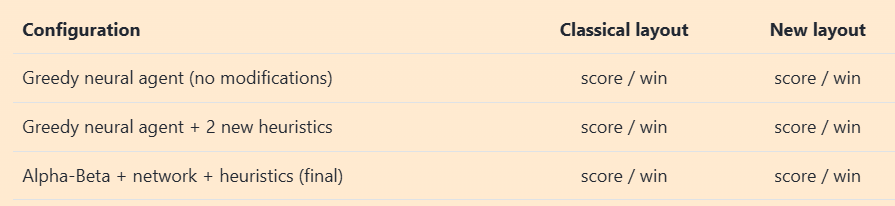

In [1]:
!python pacman.py -l mediumClassic

Reply mode: False
Pacman died! Score: 202
Datos del juego 827 guardados en pacman_data/game_827.csv
Average Score: 202.0
Scores:        202.0
Win Rate:      0/1 (0.00)
Record:        Loss


After running one game on the so-called `mediumClassic` layout, we've been able to confirm it's
just the default layout, for which we've already trained a neural net. We may train an
improved version in the future, but it will suffice for this comparison:

### 14.4.1. Creating `ExtendedNeuralAgent`

However, we must note that here our professor asks us to utilize 2 separate
versions of `NeuralAgent`:
- one with only his 2 initial heuristics
- another one with those 2 + our 2 custom heuristics

Therefore, we're going to make it so that `NeuralAgent` only uses the two original
heuristics in its `heuristic_eval()`, and we'll create a child class that overwrites
`heuristic_eval()` to also include our custom heuristics:

```
class ExtendedNeuralAgent(NeuralAgent):

    def heuristic_eval(self, state) -> float:
        """
        Additional heuristics
        -----------------------
        - Prefer going toward power capsules.
        - Avoid going for further power capsules when under the effect of one.
        - Avoid 'undoing' moves unless necessary.
        """

        # Mejorar la evaluación con conocimiento del dominio
        pacman_pos = state.getPacmanPosition()
        food = state.getFood().asList()
        ghost_states = state.getGhostStates()
        legal_actions = state.getLegalActions()

        heuristic_score: float = super().heuristic_eval(state)

        # Factor 3: Distancia a la cápsula de poder más cercana
        power_capsules = state.getCapsules()

        if power_capsules:
            power_active = any(
                g.scaredTimer > 0 for g in ghost_states
            )  # detect power capsule effect
            min_capsule_distance = min(
                manhattanDistance(pacman_pos, cap_pos) for cap_pos in power_capsules
            )

            if not power_active:
                heuristic_score += 5.0 / (min_capsule_distance + 1)
            else:
                # Strongly discourage consuming capsules while powered
                heuristic_score -= 100.0 / (min_capsule_distance + 1)

        # Factor 4: Discourage "undoing" moves
        opposites = {
            Directions.NORTH: Directions.SOUTH,
            Directions.SOUTH: Directions.NORTH,
            Directions.EAST: Directions.WEST,
            Directions.WEST: Directions.EAST,
        }

        if (
            hasattr(self, "last_action") and self.last_action in opposites
        ):  # (last move might've been STOP)
            undo = opposites[self.last_action]
            if undo in legal_actions:
                heuristic_score -= 10

        return heuristic_score
```

### 14.4.2. Part 4.2.: Actually running benchmark report

We're going to try using both the NN trained with our manual games, and the one that we
trained with `AlphaBetaAgent`'s games:

In [1]:
from utils import benchmark

agents = ["NeuralAgent"]*2 + ["ExtendedNeuralAgent"]*2 + ["AlphaBetaNeuralAgent"]*2

layouts = ["mediumClassic"]*6

model_paths = ["models/only_alpha_beta.pth", "models/only_human_games.pth"] * 3

n_games = 30

benchmark(agents=agents, layouts=layouts, neural_net_paths=model_paths, n_runs=n_games)


=== Running NeuralAgent on mediumClassic using models/only_alpha_beta.pth (30 runs) ===
done

=== Running NeuralAgent on mediumClassic using models/only_human_games.pth (30 runs) ===
done

=== Running ExtendedNeuralAgent on mediumClassic using models/only_alpha_beta.pth (30 runs) ===
done

=== Running ExtendedNeuralAgent on mediumClassic using models/only_human_games.pth (30 runs) ===
done

=== Running AlphaBetaNeuralAgent on mediumClassic using models/only_alpha_beta.pth (30 runs) ===
done

=== Running AlphaBetaNeuralAgent on mediumClassic using models/only_human_games.pth (30 runs) ===
done

======================================== BENCHMARK ========================================
Agent                     Layout          Model Path                          Runs  AvgScore   WinRate 
NeuralAgent               mediumClassic   models/only_alpha_beta.pth          30    106.0      0/30 (0.00)
NeuralAgent               mediumClassic   models/only_human_games.pth         30    87.4       

{('NeuralAgent',
  'mediumClassic',
  'models/only_alpha_beta.pth'): {'game_indices': [955,
   956,
   957,
   958,
   959,
   960,
   961,
   962,
   963,
   964,
   965,
   966,
   967,
   968,
   969,
   970,
   971,
   972,
   973,
   974,
   975,
   976,
   977,
   978,
   979,
   980,
   981,
   982,
   983,
   984], 'scores': [4.0,
   187.0,
   108.0,
   -304.0,
   -6.0,
   577.0,
   277.0,
   686.0,
   294.0,
   190.0,
   -97.0,
   152.0,
   -345.0,
   291.0,
   106.0,
   122.0,
   -224.0,
   -101.0,
   275.0,
   -321.0,
   -127.0,
   255.0,
   -147.0,
   185.0,
   303.0,
   177.0,
   94.0,
   -78.0,
   411.0,
   236.0], 'average_score': 106.0, 'win_rate': '0/30 (0.00)', 'wins': 0, 'games': 30, 'record': ['Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'L

The results are certainly interesting...

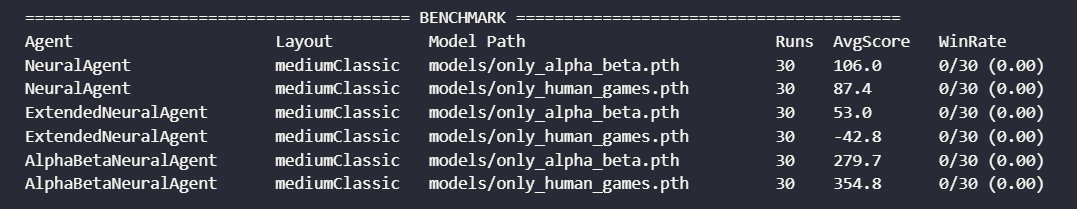

However, before commenting on them, we are going to include a new layout and make some new comparisons...

### 14.4.3. Part 4.3.: Benchmarking our agents with new layout

#### 14.4.3.0 Part 4.3.0: Creating new layout

```
%%%%%%%%%%%%%%%%%%%%
%o... ........ ....%
%.%%. .%%..%%. .%%.%
%.%..............%.%
%.%.%%.%%  %%.%%.%.%
%......%G  G%......%
%.%.%%.%%%%%%.%%.%.%
%.%..............%.%
%.%%.%.%%..%%.%.%%.%
%....%...P....%...o%
%%%%%%%%%%%%%%%%%%%%
```

*(This new layout has been saved as `layouts/customMaze.lay`).*

#### 14.4.3.1. Part 4.3.1.: Actual benchmarking with custom layout

In [2]:
agents = ["NeuralAgent"]*4 + ["ExtendedNeuralAgent"]*4 + ["AlphaBetaNeuralAgent"]*4

layouts = ["mediumClassic", "mediumClassic", "customMaze", "customMaze"]*3

model_paths = ["models/only_alpha_beta.pth", "models/only_human_games.pth"] * 6

n_games = 30

benchmark(agents=agents, layouts=layouts, neural_net_paths=model_paths, n_runs=n_games)


=== Running NeuralAgent on mediumClassic using models/only_alpha_beta.pth (30 runs) ===
done

=== Running NeuralAgent on mediumClassic using models/only_human_games.pth (30 runs) ===
done

=== Running NeuralAgent on customMaze using models/only_alpha_beta.pth (30 runs) ===
done

=== Running NeuralAgent on customMaze using models/only_human_games.pth (30 runs) ===
done

=== Running ExtendedNeuralAgent on mediumClassic using models/only_alpha_beta.pth (30 runs) ===
done

=== Running ExtendedNeuralAgent on mediumClassic using models/only_human_games.pth (30 runs) ===
done

=== Running ExtendedNeuralAgent on customMaze using models/only_alpha_beta.pth (30 runs) ===
done

=== Running ExtendedNeuralAgent on customMaze using models/only_human_games.pth (30 runs) ===
done

=== Running AlphaBetaNeuralAgent on mediumClassic using models/only_alpha_beta.pth (30 runs) ===
done

=== Running AlphaBetaNeuralAgent on mediumClassic using models/only_human_games.pth (30 runs) ===
done

=== Running Alph

{('NeuralAgent',
  'mediumClassic',
  'models/only_alpha_beta.pth'): {'game_indices': [1135,
   1136,
   1137,
   1138,
   1139,
   1140,
   1141,
   1142,
   1143,
   1144,
   1145,
   1146,
   1147,
   1148,
   1149,
   1150,
   1151,
   1152,
   1153,
   1154,
   1155,
   1156,
   1157,
   1158,
   1159,
   1160,
   1161,
   1162,
   1163,
   1164], 'scores': [-22.0,
   -338.0,
   -146.0,
   107.0,
   -76.0,
   -308.0,
   254.0,
   -344.0,
   170.0,
   662.0,
   202.0,
   -70.0,
   18.0,
   68.0,
   -10.0,
   523.0,
   -154.0,
   376.0,
   -58.0,
   127.0,
   -20.0,
   126.0,
   253.0,
   118.0,
   -37.0,
   -89.0,
   7.0,
   636.0,
   109.0,
   -27.0], 'average_score': 68.56666666666666, 'win_rate': '0/30 (0.00)', 'wins': 0, 'games': 30, 'record': ['Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss',
   'Loss'

#### 14.4.3.2. Benchmarking conclusions and take-aways

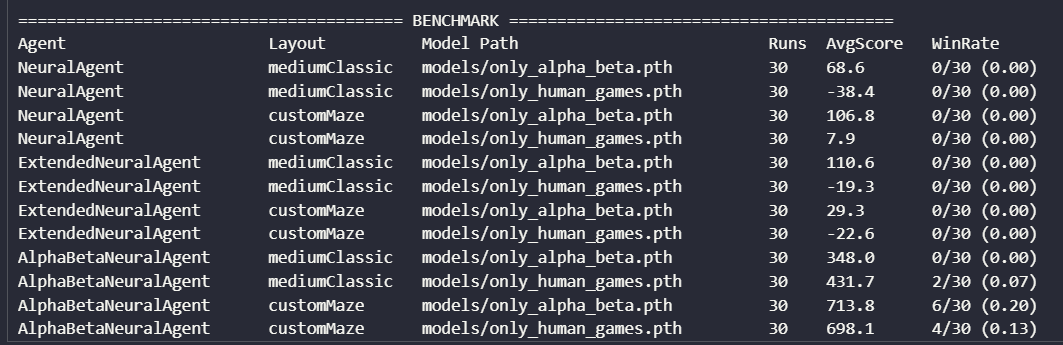

##### 14.4.3.2.1. On the outperformance of `AlphaBetaNeuralAgent`

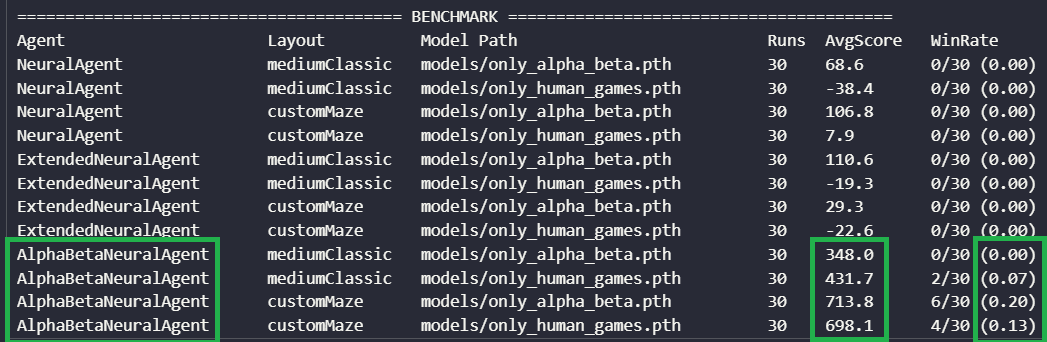

1st of all, we can clearly see that `AlphaBetaNeuralAgent` is the best performing agent
across layouts and models. This is hardly surprising, as it's the most informed:

- It anticipates the ghosts' moves via its alpha-beta search.
- It leverages past experience via its NN.

Moreover, **it's the only agent that has a positive winrate!**

##### 14.4.3.2.2. On the noisy relative performance on `NeuralAgent` vs `ExtendedNeuralAgent`

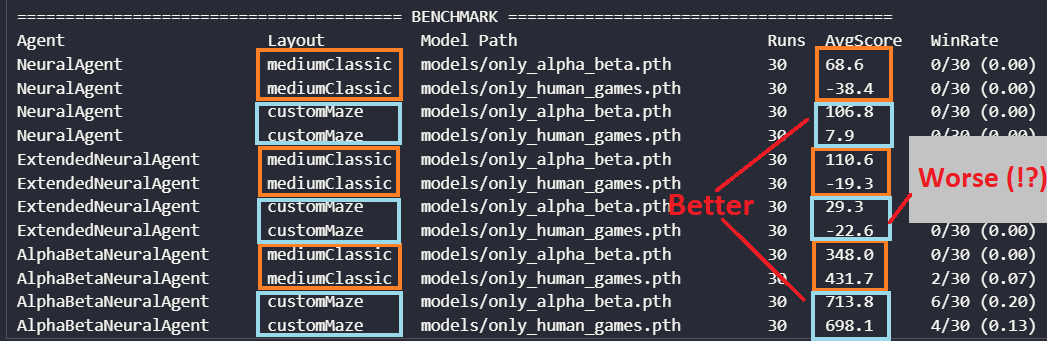
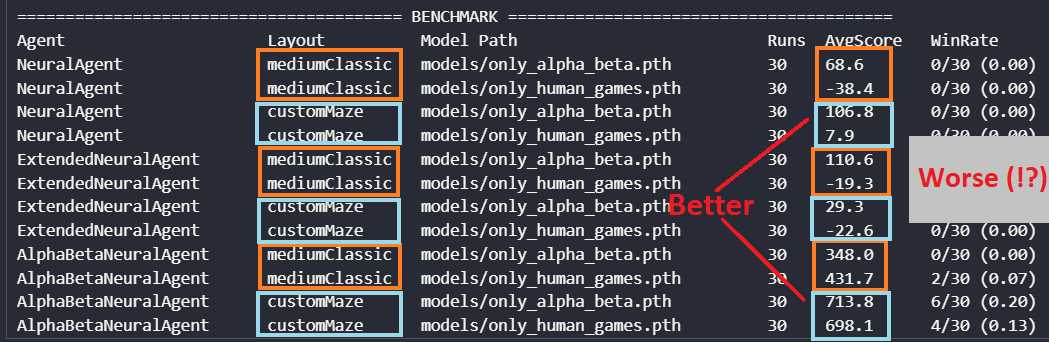

Another noteworthy thing is the fact that **default `NeuralAgent` and
`AlphaBetaNeuralAgent` perform better on the `customMaze`**, but **`ExtendedNeuralAgent`
actually performs worse**.

This strikes us as surprising. There must be some feature of `customMaze` that is
antagonistic toward our additional heuristics, namely:
- Prefer going toward power capsules
- Avoid undoing moves

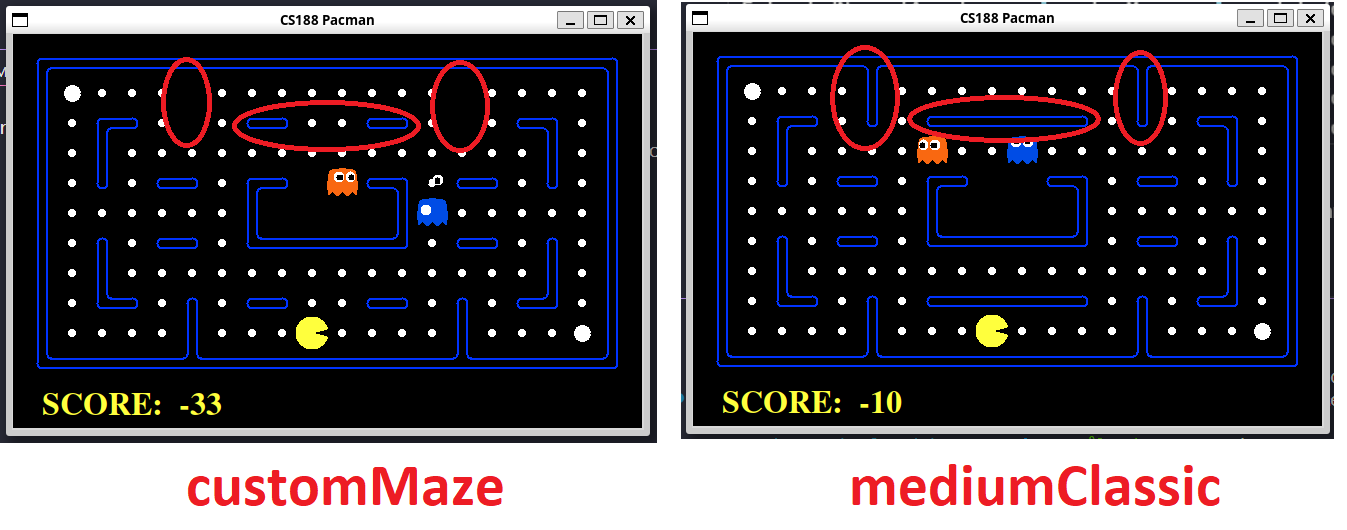

And yet, from looking at the layouts, **it is hard to ascertain why having some more open
space at the top of the layout would hurt our custom heuristics**.

If we take a look at our prior benchmark, we can see that the relative results of
`NeuralAgent` vs `ExtendedNeuralAgent` in even the `mediumClassic` layout are
inconsistent:

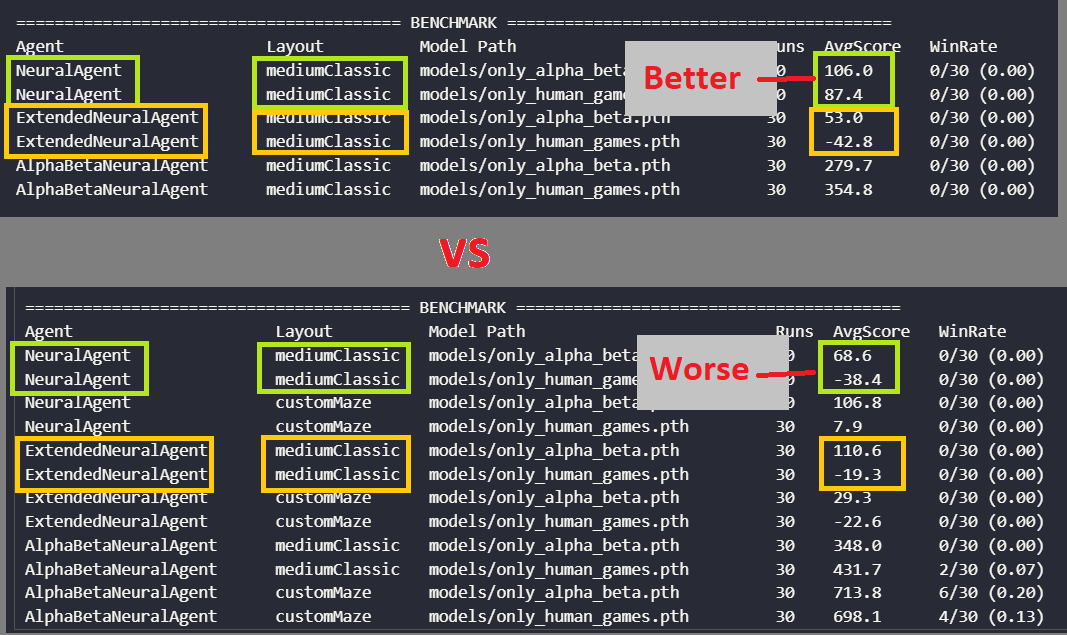
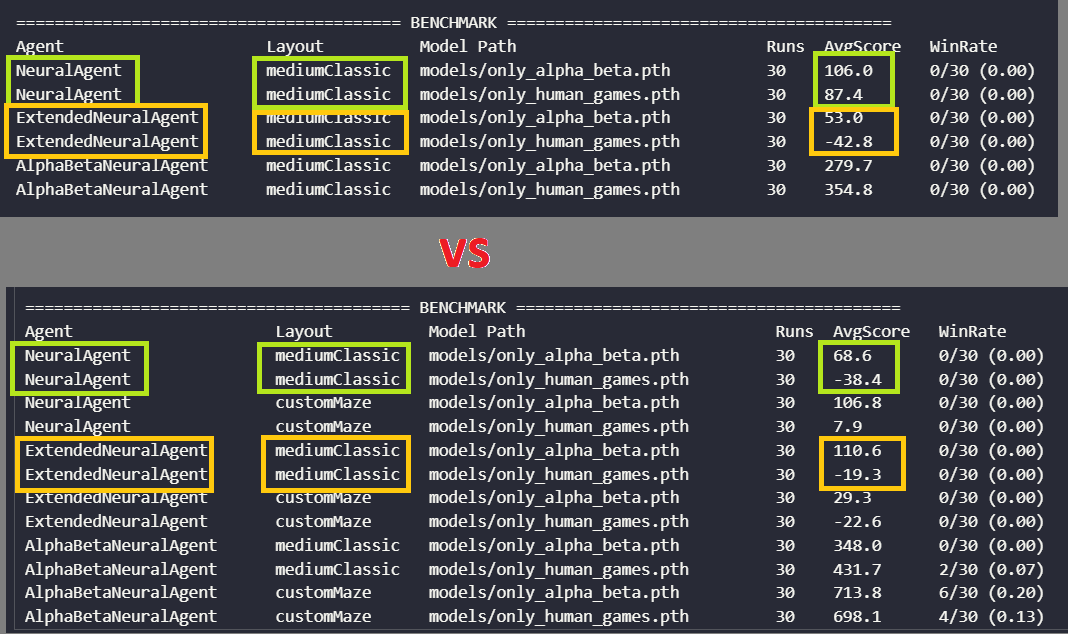

As we can see:
- `NeuralAgent` outperformed `ExtendedNeuralAgent` on the `mediumClassic` layout during
  our first benchmark run.
- But then went on to underperform during the 2nd benchmark run, in the same layout.

Therefore, we have strong reasons to believe that **the heuristics we included simply are
not informative enough, and barely move the needle when compared to plain vanilla
`NeuralAgent`**.

Given this assumption, the relative outperformance of either `NeuralAgent` or
`ExtendedNeuralAgent` may be attributable to luck.

## 14.6. Part 6: Record the video of the best game

>You must record one video: the final configuration (Alpha-Beta + network + heuristics) playing its best game. You have to record two clips:

>The best game on the mediumClassic layout.

>The best game on the new layout.

>Video requirements:

>Must be reproducible: include the exact command used to launch the game (with a fixed seed) and the corresponding trained model. If we cannot reproduce the game by executing the command you report, it will be penalized.

>No cuts in the middle of the game.

Unfortunately, at this point we've realised that, on account of having removed the
hard-coded seeds and extracted the logic away onto a `.env` file, none of our recorded
games have any seed information attached.

Therefore, it won't be enough to just look through the games we've already generated,
and **we'll have to create a bunch of new games from scratch**. This time, also printing out
seed information.

- We'll repurpose our helpers at `utils` to create a lot of new games.
- We'll also make use of the `os` library in order to set the seeds and keep track of
  the best one so far.

### 14.6.1. Part 6.1.: The `utils/find_awesome_game()` helper

```
from utils import parse_pacman_output, run_pacman
import os
import random


def find_awesome_game(
    agent: str = "AlphaBetaNeuralAgent",
    layout: str = "mediumClassic",
    model_path: str = "models/only_human_games.pth",
    n_runs: int = 100,
) -> dict:
    """
    Generates a bunch of games from scratch and keeps track of the id and seed of the
    best one so far.
    """
    best_score = float("-inf")
    best_seed = None
    best_index = None

    for i in range(n_runs):

        # Generate a fresh random seed for this run
        seed = random.randint(0, 10_000_000)

        # Inject it into the environment so Pacman uses it
        os.environ["PACMAN_SEED"] = str(seed)

        output_raw = run_pacman(
            agent=agent, layout=layout, model_path=model_path, fast=True, n_runs=1
        )
        parsed_output: dict = parse_pacman_output(output_raw)

        score: float = parsed_output["average_score"]

        print(f"[{i}] seed={seed} → score={score}")

        if score is not None and score > best_score:
            best_score = score
            best_seed = seed
            best_index = i

    return {
        "best_score": best_score,
        "best_seed": best_seed,
        "best_index": best_index,
    }
```

### 14.6.2. Part 6.2.: Generating the games

#### 14.6.2.1 Part 6.2.1: Testing that generated games are reproducible

In [1]:
!mv pacman_data/ pacman_data_copy/

In [2]:
!mkdir pacman_data

In [3]:
from utils import find_awesome_game

best_run = find_awesome_game(
    agent="AlphaBetaNeuralAgent",
    layout="mediumClassic",
    model_path="models/only_human_games.pth",
    n_runs=5,
    )

best_run

[0] seed=8574405 → score=367.0
[1] seed=5782971 → score=479.0
[2] seed=6843271 → score=24.0
[3] seed=8029643 → score=552.0
[4] seed=9551874 → score=375.0


{'best_score': 552.0, 'best_seed': 8029643, 'best_index': 3}

Aight, it seems to be working just fine. Now let's make sure we can actually "re-create"
the "best-game" we've found in this mini-test run, and get the same score:

*(we've just added the seed to `.env`)*

In [8]:
import os

os.environ["PACMAN_SEED"] = str(8029643)

In [9]:
!python pacman.py -l mediumClassic -p AlphaBetaNeuralAgent -a model_path=models/only_human_games.pth

Modelo cargado correctamente desde models/only_human_games.pth
Tamaño de entrada: (20, 11)
NeuralAgent inicializado, usando dispositivo: cuda
Reply mode: False
Pacman died! Score: 552
Datos del juego 7 guardados en pacman_data/game_7.csv
Average Score: 552.0
Scores:        552.0
Win Rate:      0/1 (0.00)
Record:        Loss


As the score obtained by setting the same seed ended up being the same as the best
reported seed, we can ascertain that our little experiments are reproducible!

Unfortunately, we tried using `.env` to set the seed to the best one, and it didn't
work. It must be set manually via `os.environ["PACMAN_SEED"]`.

#### 14.6.2.2 Part 6.2.2: Generating 100 games for `mediumClassic` layout

In [12]:
best_run = find_awesome_game(
    agent="AlphaBetaNeuralAgent",
    layout="mediumClassic",
    model_path="models/only_human_games.pth",
    n_runs=100,
    )

best_run

[0] seed=4108221 → score=764.0
[1] seed=909273 → score=284.0
[2] seed=9507103 → score=620.0
[3] seed=5440609 → score=141.0
[4] seed=2983239 → score=358.0
[5] seed=7101911 → score=400.0
[6] seed=5533631 → score=18.0
[7] seed=5288974 → score=310.0
[8] seed=9750027 → score=206.0
[9] seed=3608195 → score=333.0
[10] seed=3433960 → score=392.0
[11] seed=3024562 → score=348.0
[12] seed=3864390 → score=-123.0
[13] seed=1129711 → score=451.0
[14] seed=2801831 → score=104.0
[15] seed=9360139 → score=557.0
[16] seed=3374594 → score=390.0
[17] seed=714217 → score=688.0
[18] seed=8381075 → score=147.0
[19] seed=1777895 → score=43.0
[20] seed=1920434 → score=300.0
[21] seed=2316730 → score=404.0
[22] seed=5920819 → score=578.0
[23] seed=6486190 → score=314.0
[24] seed=6078780 → score=375.0
[25] seed=7120761 → score=1593.0
[26] seed=4906652 → score=765.0
[27] seed=2433850 → score=91.0
[28] seed=4718570 → score=578.0
[29] seed=1208572 → score=445.0
[30] seed=2445785 → score=667.0
[31] seed=7114184 → s

{'best_score': 1868.0, 'best_seed': 9475954, 'best_index': 70}

In [13]:
os.environ["PACMAN_SEED"] = str(9475954)

!python pacman.py -l mediumClassic -p AlphaBetaNeuralAgent -a model_path=models/only_human_games.pth

Modelo cargado correctamente desde models/only_human_games.pth
Tamaño de entrada: (20, 11)
NeuralAgent inicializado, usando dispositivo: cuda
Reply mode: False
Pacman emerges victorious! Score: 1868
Datos del juego 100 guardados en pacman_data/game_100.csv
Average Score: 1868.0
Scores:        1868.0
Win Rate:      1/1 (1.00)
Record:        Win


#### 14.6.2.3 Part 6.2.3: Generating 100 games for `customMaze` layout

In [14]:
best_run = find_awesome_game(
    agent="AlphaBetaNeuralAgent",
    layout="customMaze",
    model_path="models/only_human_games.pth",
    n_runs=100,
    )

best_run

[0] seed=3379551 → score=173.0
[1] seed=7228549 → score=900.0
[2] seed=4825655 → score=681.0
[3] seed=8852545 → score=1614.0
[4] seed=1624483 → score=101.0
[5] seed=4337778 → score=157.0
[6] seed=1788320 → score=769.0
[7] seed=3707846 → score=140.0
[8] seed=9423218 → score=323.0
[9] seed=6594221 → score=888.0
[10] seed=5223592 → score=448.0
[11] seed=4438303 → score=746.0
[12] seed=6608488 → score=585.0
[13] seed=7926398 → score=1835.0
[14] seed=874248 → score=839.0
[15] seed=3951705 → score=595.0
[16] seed=6707923 → score=782.0
[17] seed=3725136 → score=139.0
[18] seed=8303117 → score=817.0
[19] seed=6377700 → score=399.0
[20] seed=1472038 → score=361.0
[21] seed=2846411 → score=744.0
[22] seed=6289147 → score=790.0
[23] seed=4537872 → score=161.0
[24] seed=6539956 → score=1867.0
[25] seed=7121139 → score=132.0
[26] seed=936328 → score=643.0
[27] seed=1625945 → score=615.0
[28] seed=3357248 → score=201.0
[29] seed=7285079 → score=326.0
[30] seed=2567906 → score=825.0
[31] seed=2289319

{'best_score': 2049.0, 'best_seed': 5345815, 'best_index': 56}

In [15]:
os.environ["PACMAN_SEED"] = str(5345815)

!python pacman.py -l customMaze -p AlphaBetaNeuralAgent -a model_path=models/only_human_games.pth

Modelo cargado correctamente desde models/only_human_games.pth
Tamaño de entrada: (20, 11)
NeuralAgent inicializado, usando dispositivo: cuda
Reply mode: False
Pacman emerges victorious! Score: 2049
Datos del juego 201 guardados en pacman_data/game_201.csv
Average Score: 2049.0
Scores:        2049.0
Win Rate:      1/1 (1.00)
Record:        Win


### 14.6.3. Part 6.3.: HOW TO REPRODUCE THE GAMES

- 1st set the game seed like so:
```
os.environ["PACMAN_SEED"] = str(<SEED GOES HERE>)
```

- 2nd run the command with the appropriate layout and agent:

`!python pacman.py -l <LAYOUT GOES HERE> -p <AGENT GOES HERE> -a
model_path=models/<COMPLETE MODEL PATH>`